In [105]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree

In [106]:
dataset = pd.read_csv(r'D:\HopeAI\Training\Week9-ML and Data Science Capstone\1. Data Collection\bmw_global_sales_2018_2025.csv')
dataset

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.50,1.00
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.50,1.00
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.50,1.00
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.50,1.00
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.50,1.00
...,...,...,...,...,...,...,...,...,...,...,...
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41


In [107]:
dataset.columns

Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
      dtype='object')

In [108]:
dataset = dataset.sort_values(by=['Region', 'Model', 'Year', 'Month'])

dataset['Sales_Change'] = dataset.groupby(['Region','Model'])['Units_Sold'].pct_change()

# Create lag features
dataset['lag_1'] = dataset.groupby(['Region', 'Model'])['Units_Sold'].shift(1)
dataset['lag_2'] = dataset.groupby(['Region', 'Model'])['Units_Sold'].shift(2)
dataset['lag_3'] = dataset.groupby(['Region', 'Model'])['Units_Sold'].shift(3)

# Drop NA
dataset = dataset.dropna()


#Remove high importance columns
dataset = dataset.drop(columns=['Revenue_EUR'])

# Encoding
dataset = pd.get_dummies(dataset, columns=['Region', 'Model'], drop_first=True)


In [109]:
dataset.columns

Index(['Year', 'Month', 'Units_Sold', 'Avg_Price_EUR', 'BEV_Share',
       'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index', 'Sales_Change',
       'lag_1', 'lag_2', 'lag_3', 'Region_Europe', 'Region_RestOfWorld',
       'Region_USA', 'Model_5 Series', 'Model_MINI', 'Model_X3', 'Model_X5',
       'Model_X7', 'Model_i4', 'Model_iX'],
      dtype='object')

In [110]:
#Get the numerical columns
#dataset = dataset.sort_values(by=['Year', 'Month']).reset_index(drop=True)

X_Indep = dataset.drop(columns=['Sales_Change', 'Units_Sold'])
Y_Dep = dataset['Sales_Change']


In [111]:
#Split
#X_Train, X_Test, y_train, y_test = train_test_split(X_Indep, Y_Dep, test_size=1/3, random_state=0)

#Time Based Split

dataset = dataset.sort_values(by=['Year','Month']).reset_index(drop=True)

train_size = int(len(dataset) * 0.8)
X_Train = X_Indep.iloc[:train_size]
X_Test = X_Indep.iloc[train_size:]

y_train = Y_Dep.iloc[:train_size]
y_test = Y_Dep.iloc[train_size:]


In [112]:
#Random Forest
rfr = RandomForestRegressor(n_estimators=200, random_state=42)
rfr = RandomForestRegressor(n_estimators=200, random_state=42)
rfr.fit(X_Train, y_train)

#Gradient Boosting Regressor
# from sklearn.ensemble import GradientBoostingRegressor

# rfr = GradientBoostingRegressor(n_estimators=300, max_depth=5)
# rfr.fit(X_Train, y_train)


#XBoost

# from xgboost import XGBRegressor
# rfr = XGBRegressor(
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.05)
# rfr = rfr.fit(X_Train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [113]:
#check feature importance
pd.Series(rfr.feature_importances_, index=X_Train.columns).sort_values(ascending=False)

lag_1                 0.632381
GDP_Growth            0.049050
lag_3                 0.047963
BEV_Share             0.047219
Avg_Price_EUR         0.047021
lag_2                 0.044470
Premium_Share         0.040757
Fuel_Price_Index      0.031938
Month                 0.026335
Year                  0.007398
Region_Europe         0.004236
Model_iX              0.003437
Model_5 Series        0.003434
Model_X3              0.002925
Model_i4              0.002694
Region_USA            0.002644
Model_X5              0.002353
Region_RestOfWorld    0.001517
Model_X7              0.001304
Model_MINI            0.000925
dtype: float64

In [114]:
y_pred = rfr.predict(X_Test)
y_pred

array([ 1.02457328e+00, -7.40129706e-02, -4.13290554e-01, -2.54135041e-01,
       -1.68192154e-01, -1.16797893e-01,  2.02010807e+00,  1.02091412e+00,
       -2.83550388e-01, -2.59429284e-01, -3.31233755e-01,  8.75037414e-04,
       -2.83226814e-02,  8.45174056e-02,  9.38196737e-01, -1.40774878e-01,
        2.33196026e-01, -4.31328925e-01,  1.67073207e-02,  1.11588815e+00,
       -2.67065032e-01,  5.26184389e-02, -4.21600947e-01, -3.75995189e-01,
       -3.71480490e-02,  8.08626615e-02, -3.93684728e-01,  1.00975959e+00,
       -3.25423098e-01, -4.20212355e-01, -2.17043936e-01,  4.88813790e-03,
       -1.64814248e-01, -1.81532550e-02, -3.57616486e-01, -3.45773919e-01,
        1.98054874e+00, -1.60502422e-01, -2.54018877e-01, -4.33457661e-01,
        2.23596806e-01, -3.88044564e-01, -1.18231063e-01,  7.72490826e-01,
        2.15211738e+00, -2.84558336e-01,  4.99040720e-02,  3.42424097e-01,
        4.37909323e-01,  3.72660351e-01,  6.71676827e-02, -3.17692752e-01,
        1.31062920e-01,  

In [115]:
#Accuracy check
r2 = r2_score(y_test,y_pred)
print(r2)

0.5433623881242786


In [117]:
rfr.feature_importances_

array([0.00739765, 0.02633497, 0.0470209 , 0.04721948, 0.04075698,
       0.04905028, 0.0319383 , 0.6323807 , 0.04446978, 0.04796262,
       0.00423627, 0.0015166 , 0.00264379, 0.00343353, 0.00092528,
       0.00292524, 0.00235316, 0.00130381, 0.00269404, 0.00343663])

In [118]:
rfr.max_features

'auto'

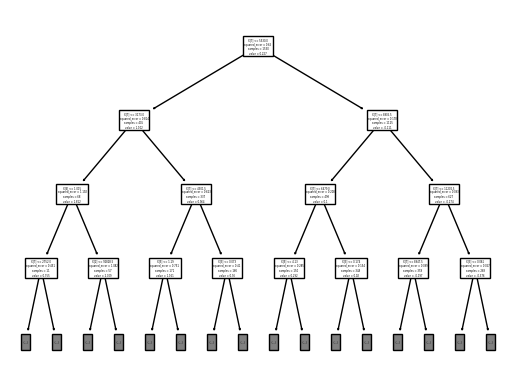

In [119]:
tree.plot_tree(rfr.estimators_[0], max_depth=3)
plt.show()